# 📚 BÀI TẬP PHÂN CỤM SINH VIÊN BẰNG K-MEANS
## Phân loại sinh viên thành 3 nhóm dựa trên điểm số

**Mục đích:**
- Phân loại sinh viên: Giỏi / Khá / Trung bình
- Chia học bổng
- Xác định các bạn cùng nhóm học lực tương đương

**Kỹ thuật sử dụng:** k-Means Clustering với Pipeline (Chương 38-39)

---
## 1️⃣ PHẦN 1: NHẬP THƯ VIỆN VÀ ĐỌC DỮ LIỆU

In [236]:
# Nhập các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Cài đặt hiển thị
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Các thư viện đã được nhập thành công!")

✅ Các thư viện đã được nhập thành công!


### Đọc và xem cấu trúc dữ liệu

In [237]:
# Đọc file Excel
file_path = 'diemv2.xlsx'
df_raw = pd.read_excel(file_path)

print("📊 THÔNG TIN DỮ LIỆU GỐC:")
print(f"Kích thước: {df_raw.shape[0]} hàng × {df_raw.shape[1]} cột")
print(f"\n5 hàng đầu tiên (15 cột):")
print(df_raw.iloc[:5, :15])

📊 THÔNG TIN DỮ LIỆU GỐC:
Kích thước: 55 hàng × 74 cột

5 hàng đầu tiên (15 cột):
  TỔNG HỢP ĐIỂM\n(Từ kỳ 1 năm nhất - hết kỳ 2 năm 4)\n(Mỗi sv tự nhập Điểm TK (4))  \
0                                                NaN                                 
1                                                NaN                                 
2                                                STT                                 
3                                                  1                                 
4                                                  2                                 

   Unnamed: 1                          STT                    1  \
0         NaN                         MSSV        K225480106002   
1         NaN                Tên Sinh Viên      Nguyễn Tuấn Anh   
2  Mã Môn học                  Tên Môn học                  NaN   
3     TEE0432  Kỹ thuật lập trình nâng cao  2026-05-02 00:00:00   
4     TEE0591  Trí tuệ nhân tạo và học máy  2026-05-03 00:00:00   


---
## 2️⃣ PHẦN 2: TIỀN XỬ LÝ DỮ LIỆU

### Bước 1: Chuyển đổi dữ liệu từ ngang sang dọc (Transpose)

In [238]:
# Dữ liệu được sắp xếp ngang:
# - Hàng 0: MSSV (Mã sinh viên)
# - Hàng 1: Tên sinh viên
# - Hàng 2 trở đi: Các môn học + điểm số

# Lấy MSSV
mssv = df_raw.iloc[0, 3:].values
mssv = [str(x) for x in mssv if pd.notna(x)]

# Lấy tên sinh viên
ten_sv = df_raw.iloc[1, 3:].values
ten_sv = [str(x) for x in ten_sv if pd.notna(x)]

# Lấy dữ liệu điểm (bắt đầu từ hàng 3, cột 3)
# Hàng 2 là header của các môn học
mon_hoc_names = df_raw.iloc[3:, 2].values  # Tên môn học
mon_hoc_codes = df_raw.iloc[3:, 1].values  # Mã môn học

# Lấy điểm số (transpose để sinh viên là hàng, môn học là cột)
diem = df_raw.iloc[3:, 3:len(mssv)+3].values.T

# Tạo DataFrame mới với cấu trúc đúng
df = pd.DataFrame(
    diem,
    columns=[f"{code}_{name}" for code, name in zip(mon_hoc_codes, mon_hoc_names)],
    index=ten_sv[:len(diem)]
)

# Chuyển đổi tất cả cột thành kiểu số
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("📋 DỮ LIỆU ĐƯỢC CHUYỂN ĐỔI:")
print(f"Sinh viên: {df.shape[0]}, Môn học: {df.shape[1]}")
print(f"\nThông tin:")
print(df.info())
print(f"\n5 sinh viên đầu tiên, 5 môn học đầu:")
print(df.iloc[:5, :5])

📋 DỮ LIỆU ĐƯỢC CHUYỂN ĐỔI:
Sinh viên: 71, Môn học: 52

Thông tin:
<class 'pandas.core.frame.DataFrame'>
Index: 71 entries, Nguyễn Tuấn Anh to Lương Hoàng Việt
Data columns (total 52 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   TEE0432_Kỹ thuật lập trình nâng cao              63 non-null     float64
 1   TEE0591_Trí tuệ nhân tạo và học máy              61 non-null     float64
 2   TEE321_Xử lý ảnh                                 64 non-null     float64
 3   WSH442_Thực tập chuyên ngành Công nghệ phần mềm  62 non-null     float64
 4   TEE0480_Công nghệ phần mềm                       62 non-null     float64
 5   TEE0497_Quản lý dự án công nghệ thông tin        63 non-null     float64
 6   TEE318_An toàn và bảo mật thông tin              60 non-null     float64
 7   TEE445_Phát triển ứng dụng trên nền web          64 non-null     float64
 8   TEE0479_Lập trình Pytho

### Bước 2: Xử lý dữ liệu thiếu (Imputation)

In [239]:
# Kiểm tra giá trị thiếu
print("🔍 THỐNG KÊ GIÁTRỊ THIẾU:")
missing_info = pd.DataFrame({
    'Số NaN': df.isnull().sum(),
    'Tỷ lệ (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

print(f"\nTổng cộng giá trị thiếu: {df.isnull().sum().sum()} / {df.size}")
print(f"Số môn học có dữ liệu thiếu: {(df.isnull().sum() > 0).sum()}")
print(f"\n10 môn học có nhiều NaN nhất:")
print(missing_info.sort_values('Số NaN', ascending=False).head(10))

# Tạo một bản sao để xử lý
df_clean = df.copy()

# Loại bỏ các môn học có quá nhiều giá trị thiếu (> 50%)
cols_to_drop = df_clean.columns[df_clean.isnull().mean() > 0.5]
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"\n🗑️ Đã loại bỏ {len(cols_to_drop)} môn học có NaN > 50%")
print(f"Còn lại: {df_clean.shape[1]} môn học")

# Điền giá trị thiếu bằng trung bình của cột (mean imputation)
imputer = SimpleImputer(strategy='mean')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns,
    index=df_clean.index
)

print(f"\n✅ Đã điền NaN bằng trung bình cột")
print(f"Giá trị thiếu còn lại: {df_imputed.isnull().sum().sum()}")
print(f"\nDữ liệu sau xử lý:")
print(df_imputed.head())

🔍 THỐNG KÊ GIÁTRỊ THIẾU:

Tổng cộng giá trị thiếu: 500 / 3692
Số môn học có dữ liệu thiếu: 52

10 môn học có nhiều NaN nhất:
                             Số NaN  Tỷ lệ (%)
B103BC1_Bóng chuyền 1            40      56.34
ENG217_Tiếng Anh 3               18      25.35
B103BR1_Bóng rổ 1                15      21.13
BAS0205_Giải tích 2              14      19.72
FIM402_Quản lý chất lượng        14      19.72
TEE402_Đồ án hệ thống nhúng      13      18.31
TEE0217_Thiết kế logic số        13      18.31
TEE317_Toán rời rạc              12      16.90
BAS111_Vật lý 1                  12      16.90
TEE403_Hệ thống nhúng            12      16.90

🗑️ Đã loại bỏ 1 môn học có NaN > 50%
Còn lại: 51 môn học

✅ Đã điền NaN bằng trung bình cột
Giá trị thiếu còn lại: 0

Dữ liệu sau xử lý:
                 TEE0432_Kỹ thuật lập trình nâng cao  \
Nguyễn Tuấn Anh                             2.906349   
Nguyễn Tuấn Anh                             3.000000   
Bùi Ngọc Anh                                3.000000

### Bước 3: Thống kê mô tả dữ liệu

In [240]:
print("📈 THỐNG KÊ MÔ TẢ:")
print(df_imputed.describe().round(3))

# Tính điểm TB cho từng sinh viên
diem_tb = df_imputed.mean(axis=1).sort_values(ascending=False)

print("\n🎓 ĐIỂM TRUNG BÌNH CỦA TỪNG SINH VIÊN:")
print(diem_tb.round(2))

# Phân loại đơn giản
print("\n📊 PHÂN LOẠI NHANH (dựa trên điểm TB):")
print(f"Giỏi (≥3.5): {(diem_tb >= 3.5).sum()} sinh viên")
print(f"Khá (3.0-3.5): {((diem_tb >= 3.0) & (diem_tb < 3.5)).sum()} sinh viên")
print(f"Trung bình (<3.0): {(diem_tb < 3.0).sum()} sinh viên")

📈 THỐNG KÊ MÔ TẢ:
       TEE0432_Kỹ thuật lập trình nâng cao  \
count                               71.000   
mean                                 2.906   
std                                  0.421   
min                                  1.500   
25%                                  2.906   
50%                                  3.000   
75%                                  3.000   
max                                  4.000   

       TEE0591_Trí tuệ nhân tạo và học máy  TEE321_Xử lý ảnh  \
count                               71.000            71.000   
mean                                 3.074             2.720   
std                                  0.571             0.859   
min                                  1.500             1.000   
25%                                  3.000             2.250   
50%                                  3.000             3.000   
75%                                  3.500             3.000   
max                                  4.000             

---
## 3️⃣ PHẦN 3: XÂY DỰNG PIPELINE VÀ PHÂN CỤUM K-MEANS

### Bước 1: Tìm k tối ưu bằng Elbow Method

D:\Anaconda\envs\my_ml_dev_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\envs\my_ml_dev_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\envs\my_ml_dev_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\envs\my_ml_dev_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have

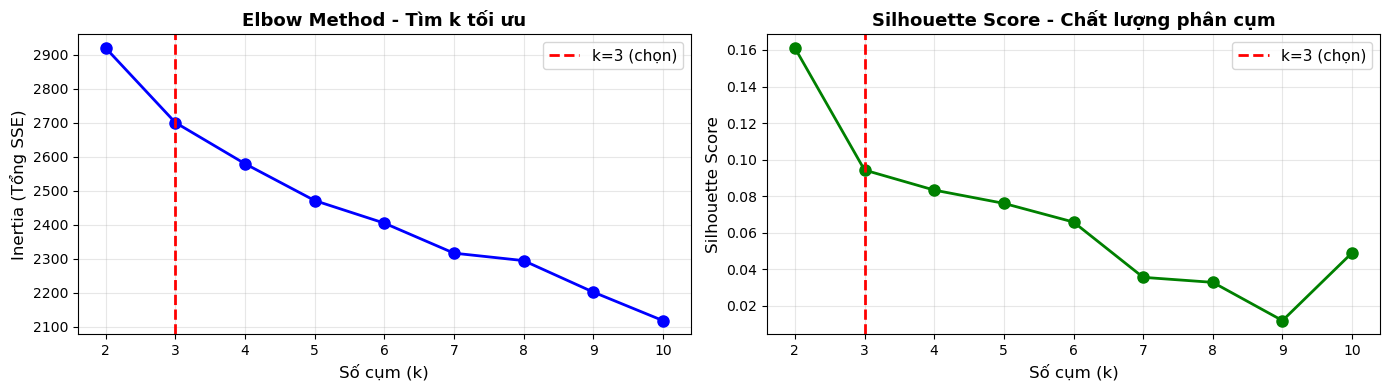

📊 KẾT QUẢ ELBOW METHOD & SILHOUETTE SCORE:
K     Inertia         Silhouette Score    
----------------------------------------
2     2920.63         0.1611               
3     2700.97         0.0943               ← Chọn
4     2579.62         0.0833               
5     2471.19         0.0761               
6     2404.65         0.0659               
7     2316.18         0.0356               
8     2294.19         0.0329               
9     2201.50         0.0119               
10    2117.49         0.0491               


In [241]:
# Elbow Method để xác định số cụm tối ưu
inertias = []
silhouette_scores = []
K_range = range(2, 11)

# Chuẩn hóa dữ liệu trước
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed)

# Tính inertia cho từng k
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Vẽ biểu đồ Elbow
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow curve
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (chọn)')
axes[0].set_xlabel('Số cụm (k)', fontsize=12)
axes[0].set_ylabel('Inertia (Tổng SSE)', fontsize=12)
axes[0].set_title('Elbow Method - Tìm k tối ưu', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)

# Silhouette score
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='k=3 (chọn)')
axes[1].set_xlabel('Số cụm (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score - Chất lượng phân cụm', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 KẾT QUẢ ELBOW METHOD & SILHOUETTE SCORE:")
print(f"{'K':<5} {'Inertia':<15} {'Silhouette Score':<20}")
print("-" * 40)
for k, inertia, sil_score in zip(K_range, inertias, silhouette_scores):
    marker = "← Chọn" if k == 3 else ""
    print(f"{k:<5} {inertia:<15.2f} {sil_score:<20.4f} {marker}")

### Bước 2: Tạo Pipeline và huấn luyện mô hình

In [242]:
# ============================================================
# PIPELINE: Chuẩn hóa → K-Means
# ============================================================

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, random_state=42, n_init=10))
])

# Huấn luyện mô hình
print("🚀 Đang huấn luyện mô hình k-Means...")
pipeline.fit(df_imputed)
print("✅ Hoàn thành!")

# Lấy nhãn cụm
clusters = pipeline.predict(df_imputed)

# Thêm nhãn cụm vào DataFrame
df_imputed['Cụm'] = clusters

# Lấy centroid (đã chuẩn hóa)
kmeans_model = pipeline.named_steps['kmeans']
centroids_scaled = kmeans_model.cluster_centers_

print("\n📊 KẾT QUẢ PHÂN CỤUM:")
print(f"Tổng sinh viên: {len(clusters)}")
print(f"\nPhân phối sinh viên theo cụm:")
for cluster_id in range(3):
    count = (clusters == cluster_id).sum()
    print(f"  Cụm {cluster_id}: {count} sinh viên ({count/len(clusters)*100:.1f}%)")

print(f"\nInertia (tổng SSE): {kmeans_model.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, clusters):.4f}")

🚀 Đang huấn luyện mô hình k-Means...
✅ Hoàn thành!

📊 KẾT QUẢ PHÂN CỤUM:
Tổng sinh viên: 71

Phân phối sinh viên theo cụm:
  Cụm 0: 23 sinh viên (32.4%)
  Cụm 1: 28 sinh viên (39.4%)
  Cụm 2: 20 sinh viên (28.2%)

Inertia (tổng SSE): 2700.97
Silhouette Score: 0.0943


D:\Anaconda\envs\my_ml_dev_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Bước 3: Phân tích đặc trưng của từng cụm

In [243]:
print("🎯 PHÂN TÍCH CÁC CỤUM:")
print("="*80)

# Tính điểm trung bình của từng cụm
for cluster_id in range(3):
    cluster_data = df_imputed[df_imputed['Cụm'] == cluster_id].drop('Cụm', axis=1)

    # Tính trung bình từng môn
    mean_scores = cluster_data.mean()
    overall_mean = mean_scores.mean()

    print(f"\n🔷 CỤM {cluster_id}:")
    print(f"  Số sinh viên: {len(cluster_data)}")
    print(f"  Điểm TB chung: {overall_mean:.2f}")
    print(f"  Sinh viên: {', '.join(cluster_data.index.tolist())}")

print("\n" + "="*80)

🎯 PHÂN TÍCH CÁC CỤUM:

🔷 CỤM 0:
  Số sinh viên: 23
  Điểm TB chung: 3.13
  Sinh viên: Lý Văn Cường, Nguyễn Đức Dương, Đặng Đình Đạt, Trần Thị Thu Hà, Lường Văn Hạnh, Nguyễn Thị Thu Hiền, Hứa Thị Thanh Hiền, Nguyễn Trung Hiếu, Lương Văn Học, Nguyễn Thị Kim Huệ, Hầu Thị Thanh Huyền, Vũ Bảo Khánh, Đậu Văn Khánh, Nguyễn Như Khiêm, Nguyễn Nguyệt Linh, Nguyễn Thị Linh, Dương Thị Ly, Hoàng Kim Ngọc, Hoàng Thị Quyến, Phạm Mạnh Quỳnh, Nguyễn Tiến Thắng, Nguyễn Văn Thứ, Lương Hoàng Việt

🔷 CỤM 1:
  Số sinh viên: 28
  Điểm TB chung: 2.64
  Sinh viên: Nguyễn Tuấn Anh, Lê Tuấn Anh, Nguyễn Khánh Duy, Nguyễn Thế Dương, Ngụy Đình Tuấn Hà, Trần Quang Hiệp, Ma Quốc Hiếu, Nguyễn Mạnh Hiếu, Nguyễn Văn Hoan, Vũ Lân, Ngô Thị Thùy Linh, Phạm Khắc Linh, Nguyễn Giang Long, Phạm Duy Tiến Minh, Dương Quang Minh, Nguyễn Thị Hằng Nga, Phương Thị Ánh Nguyệt, Nông Hồ Nhật, Hầu Nhật Ninh, Nguyễn Thị Xuân Phương, Thân Nhân Thành, Hoàng Thị Xuân Trang, Lê Ngọc Tú, Nguyễn Đức Anh Tú, Nguyễn Đình Tú, Vũ Đức Tú, Nguyễn Đứ

---
## 4️⃣ PHẦN 4: TRỰC QUAN HÓA DỮ LIỆU

### Bước 1: PCA 2D để hiển thị các cụm

🔍 PCA ANALYSIS:
Variance explained by PC1: 28.18%
Variance explained by PC2: 6.34%
Total variance: 34.52%


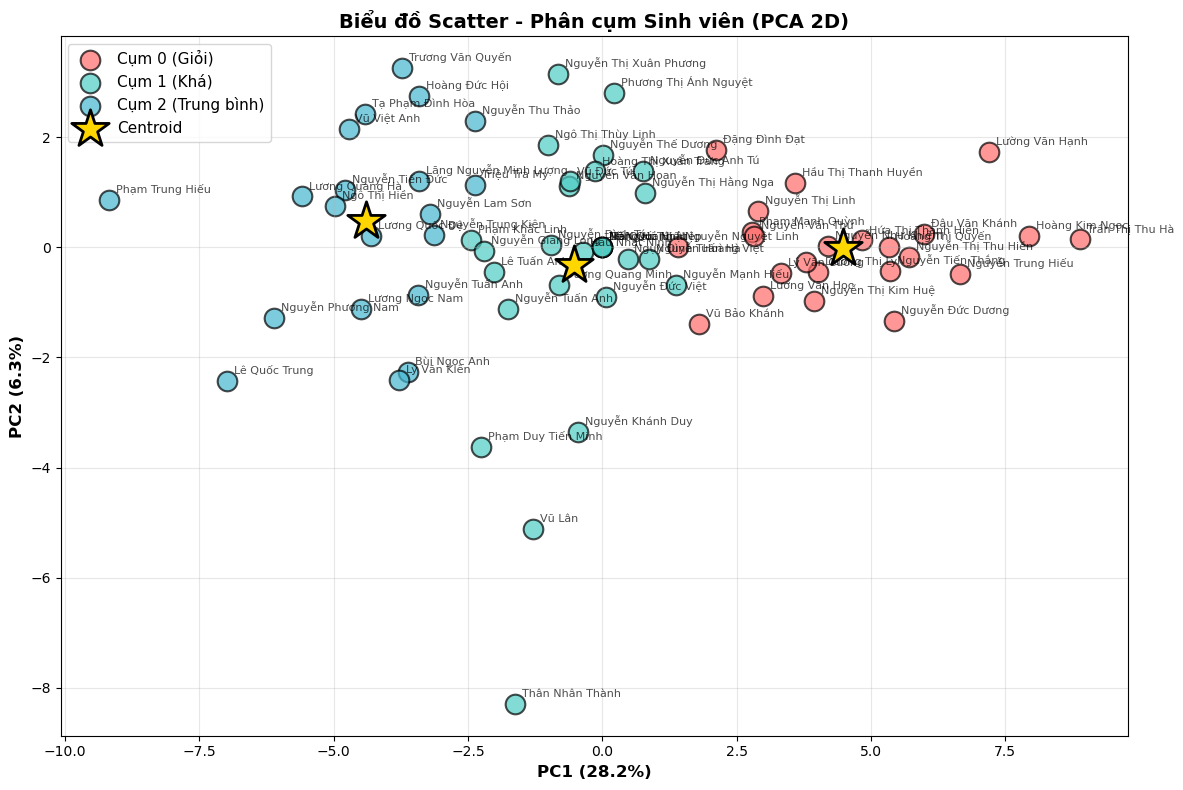

✅ Biểu đồ PCA 2D đã được lưu!


In [244]:
# Áp dụng PCA để giảm chiều xuống 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"🔍 PCA ANALYSIS:")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total variance: {sum(pca.explained_variance_ratio_):.2%}")

# Vẽ biểu đồ scatter
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cluster_names = ['Cụm 0 (Giỏi)', 'Cụm 1 (Khá)', 'Cụm 2 (Trung bình)']

# Vẽ các điểm sinh viên
for cluster_id in range(3):
    mask = clusters == cluster_id
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        s=200,
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5
    )

# Vẽ centroid đã transform qua PCA
centroids_pca = pca.transform(centroids_scaled)
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='gold',
    marker='*',
    s=800,
    edgecolors='black',
    linewidth=2,
    label='Centroid',
    zorder=5
)

# Thêm tên sinh viên
for i, name in enumerate(df_imputed.index[:-1]):
    ax.annotate(
        name,
        (X_pca[i, 0], X_pca[i, 1]),
        fontsize=8,
        alpha=0.7,
        xytext=(5, 5),
        textcoords='offset points'
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('Biểu đồ Scatter - Phân cụm Sinh viên (PCA 2D)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_2d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Biểu đồ PCA 2D đã được lưu!")

### Bước 2: PCA 3D để hiển thị tốt hơn

📊 PCA 3D ANALYSIS:
Variance explained: 39.63%


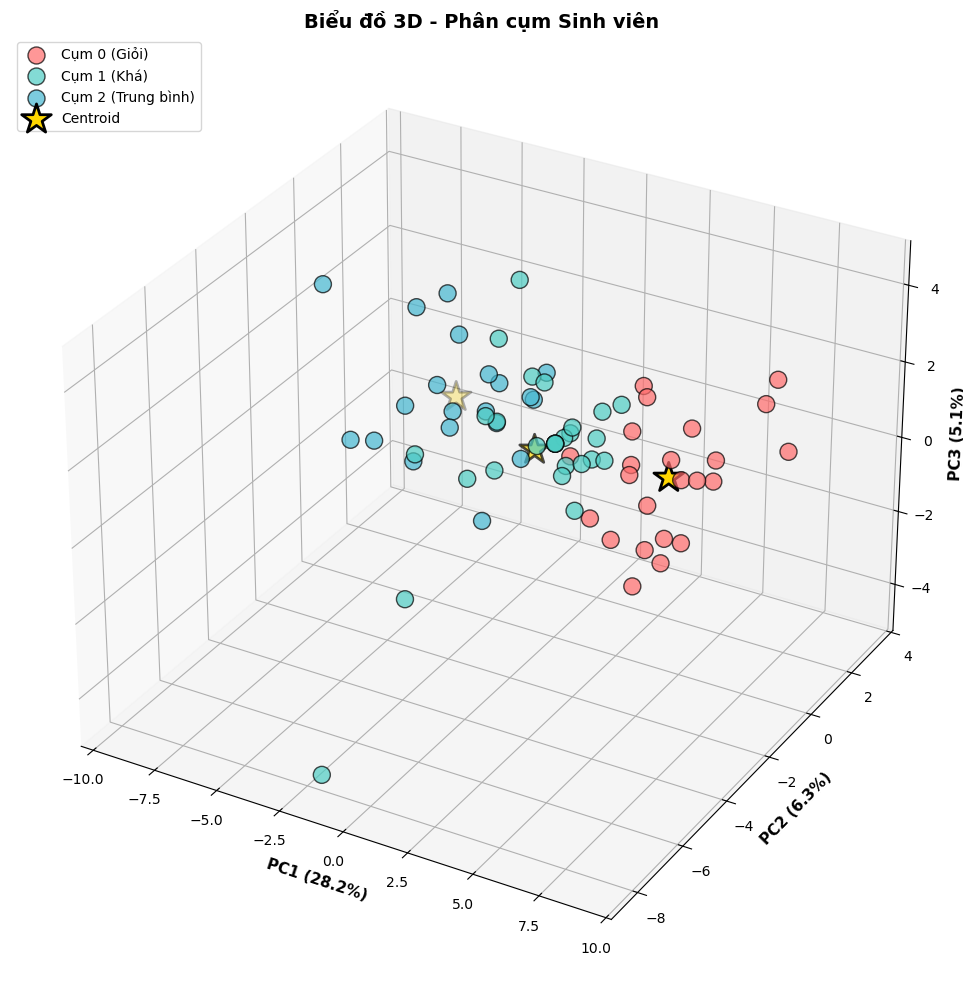

✅ Biểu đồ PCA 3D đã được lưu!


In [245]:
from mpl_toolkits.mplot3d import Axes3D

# Áp dụng PCA 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"📊 PCA 3D ANALYSIS:")
print(f"Variance explained: {sum(pca_3d.explained_variance_ratio_):.2%}")

# Vẽ biểu đồ 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cluster_names = ['Cụm 0 (Giỏi)', 'Cụm 1 (Khá)', 'Cụm 2 (Trung bình)']

for cluster_id in range(3):
    mask = clusters == cluster_id
    ax.scatter(
        X_pca_3d[mask, 0],
        X_pca_3d[mask, 1],
        X_pca_3d[mask, 2],
        c=colors[cluster_id],
        label=cluster_names[cluster_id],
        s=150,
        alpha=0.7,
        edgecolors='black',
        linewidth=1
    )

# Vẽ centroid 3D
centroids_pca_3d = pca_3d.transform(centroids_scaled)
ax.scatter(
    centroids_pca_3d[:, 0],
    centroids_pca_3d[:, 1],
    centroids_pca_3d[:, 2],
    c='gold',
    marker='*',
    s=500,
    edgecolors='black',
    linewidth=2,
    label='Centroid',
    zorder=5
)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontsize=11, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontsize=11, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontsize=11, fontweight='bold')
ax.set_title('Biểu đồ 3D - Phân cụm Sinh viên', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('pca_3d_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Biểu đồ PCA 3D đã được lưu!")

### Bước 3: So sánh điểm trung bình của các cụm

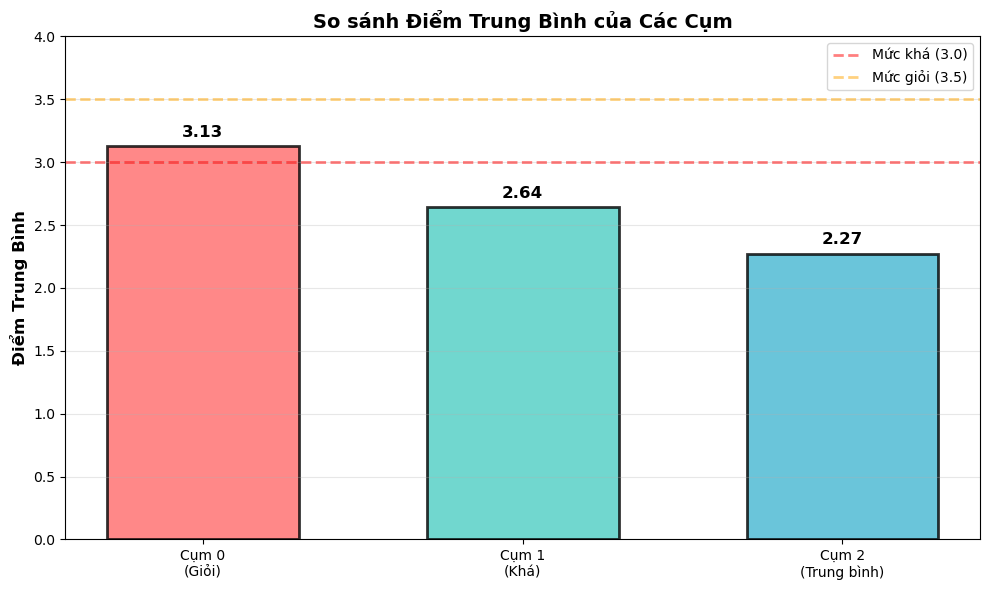

📊 ĐIỂM TRUNG BÌNH CỦA CÁC CỤUM:
Cụm 0: 3.13
Cụm 1: 2.64
Cụm 2: 2.27


In [246]:
# Tính điểm TB cho từng cụm
cluster_means = []
for cluster_id in range(3):
    cluster_data = df_imputed[df_imputed['Cụm'] == cluster_id].drop('Cụm', axis=1)
    cluster_means.append(cluster_data.mean().mean())

# Vẽ biểu đồ cột
fig, ax = plt.subplots(figsize=(10, 6))

colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1']
cluster_names = ['Cụm 0\n(Giỏi)', 'Cụm 1\n(Khá)', 'Cụm 2\n(Trung bình)']

bars = ax.bar(
    cluster_names,
    cluster_means,
    color=colors_bar,
    edgecolor='black',
    linewidth=2,
    width=0.6,
    alpha=0.8
)

# Thêm giá trị trên cột
for bar, mean in zip(bars, cluster_means):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.05,
        f'{mean:.2f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Thêm đường tham chiếu
ax.axhline(y=3.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mức khá (3.0)')
ax.axhline(y=3.5, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Mức giỏi (3.5)')

ax.set_ylabel('Điểm Trung Bình', fontsize=12, fontweight='bold')
ax.set_title('So sánh Điểm Trung Bình của Các Cụm', fontsize=14, fontweight='bold')
ax.set_ylim([0, 4.0])
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_means_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 ĐIỂM TRUNG BÌNH CỦA CÁC CỤUM:")
for i, mean in enumerate(cluster_means):
    print(f"Cụm {i}: {mean:.2f}")

### Bước 4: Silhouette Plot

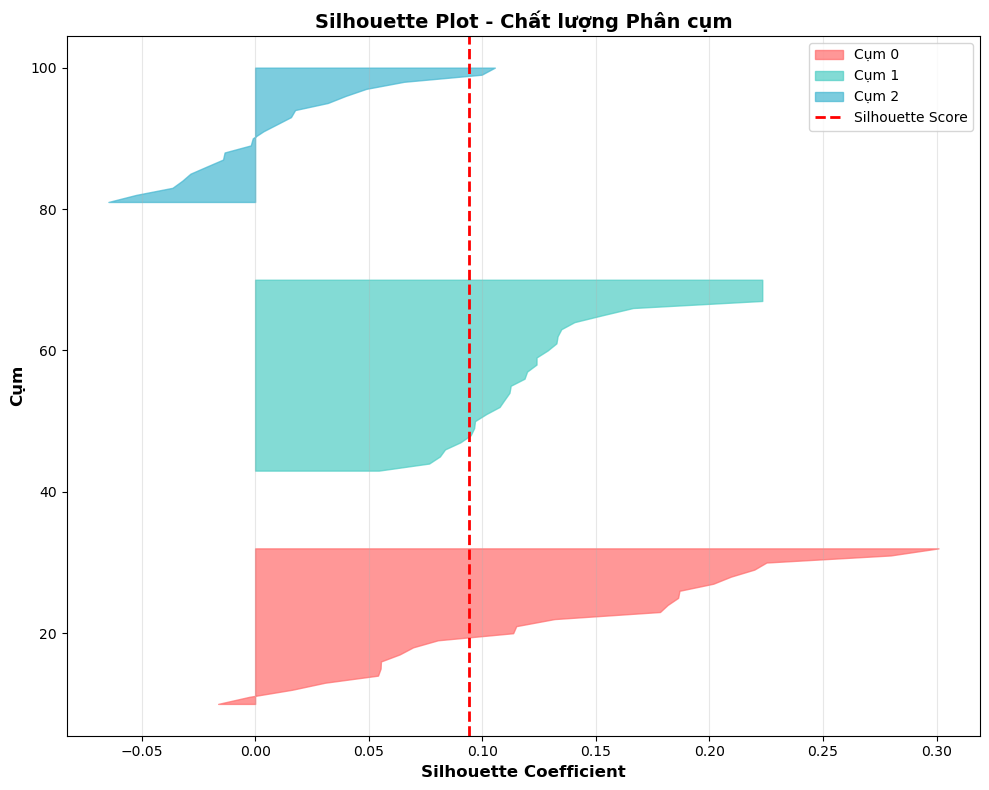

✅ Silhouette Plot đã được lưu!


In [247]:
# Tính silhouette values
silhouette_vals = silhouette_samples(X_scaled, clusters)

fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
colors_sil = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for i in range(3):
    cluster_silhouette_vals = silhouette_vals[clusters == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        facecolor=colors_sil[i],
        edgecolor=colors_sil[i],
        alpha=0.7,
        label=f'Cụm {i}'
    )
    
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, clusters), color='red', linestyle='--', linewidth=2, label='Silhouette Score')
ax.set_xlabel('Silhouette Coefficient', fontsize=12, fontweight='bold')
ax.set_ylabel('Cụm', fontsize=12, fontweight='bold')
ax.set_title('Silhouette Plot - Chất lượng Phân cụm', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Silhouette Plot đã được lưu!")

---
## 5️⃣ PHẦN 5: KẾT QUẢ PHÂN TÍCH & ỨNG DỤNG THỰC TẾ

### Danh sách sinh viên theo cụm

In [248]:
print("\n" + "="*100)
print("📋 DANH SÁCH SINH VIÊN THEO CỤU")
print("="*100)

for cluster_id in range(3):
    cluster_data = df_imputed[df_imputed['Cụm'] == cluster_id].copy()
    cluster_data = cluster_data.drop('Cụm', axis=1)
    
    # Tính điểm TB cho mỗi sinh viên
    cluster_data['ĐTB'] = cluster_data.mean(axis=1)
    cluster_data = cluster_data.sort_values('ĐTB', ascending=False)
    
    print(f"\n🔷 CỤM {cluster_id}:")
    print(f"Số lượng: {len(cluster_data)} sinh viên")
    print(f"\n{'STT':<5} {'Tên Sinh Viên':<30} {'Điểm TB':<12}")
    print("-" * 50)
    
    for idx, (name, row) in enumerate(cluster_data.iterrows(), 1):
        diem_tb = row['ĐTB']
        print(f"{idx:<5} {name:<30} {diem_tb:<12.2f}")


📋 DANH SÁCH SINH VIÊN THEO CỤU

🔷 CỤM 0:
Số lượng: 23 sinh viên

STT   Tên Sinh Viên                  Điểm TB     
--------------------------------------------------
1     Trần Thị Thu Hà                3.55        
2     Hoàng Kim Ngọc                 3.44        
3     Nguyễn Trung Hiếu              3.38        
4     Lường Văn Hạnh                 3.36        
5     Nguyễn Thị Thu Hiền            3.25        
6     Nguyễn Đức Dương               3.24        
7     Nguyễn Tiến Thắng              3.24        
8     Đậu Văn Khánh                  3.23        
9     Hoàng Thị Quyến                3.20        
10    Hứa Thị Thanh Hiền             3.16        
11    Dương Thị Ly                   3.13        
12    Nguyễn Như Khiêm               3.08        
13    Hầu Thị Thanh Huyền            3.07        
14    Lương Hoàng Việt               3.05        
15    Nguyễn Thị Kim Huệ             3.03        
16    Lý Văn Cường                   3.03        
17    Nguyễn Thị Linh            

### Phân tích chi tiết: Môn học đạt/không đạt của từng cụm

In [249]:
print("\n" + "="*100)
print("📊 PHÂN TÍCH CHI TIẾT: ĐIỂM TB CỦA TỪNG MÔN HỌC THEO CỤM")
print("="*100)

# Top môn học tốt/xấu cho từng cụm
for cluster_id in range(3):
    cluster_data = df_imputed[df_imputed['Cụm'] == cluster_id].drop('Cụm', axis=1)
    
    # Tính trung bình mỗi môn
    mon_avg = cluster_data.mean().sort_values(ascending=False)
    
    print(f"\n🔷 CỤM {cluster_id}:")
    print(f"\n  🏆 TOP 5 môn học MẠNH:")
    for i, (mon, diem) in enumerate(mon_avg.head(5).items(), 1):
        mon_name = mon.split('_', 1)[1] if '_' in mon else mon
        print(f"    {i}. {mon_name:<40} {diem:>6.2f}")
    
    print(f"\n  ⚠️  TOP 5 môn học YẾU:")
    for i, (mon, diem) in enumerate(mon_avg.tail(5).sort_values().items(), 1):
        mon_name = mon.split('_', 1)[1] if '_' in mon else mon
        print(f"    {i}. {mon_name:<40} {diem:>6.2f}")


📊 PHÂN TÍCH CHI TIẾT: ĐIỂM TB CỦA TỪNG MÔN HỌC THEO CỤM

🔷 CỤM 0:

  🏆 TOP 5 môn học MẠNH:
    1. Lập trình Python                           3.80
    2. Hệ quản trị cơ sở dữ liệu                  3.77
    3. An toàn và bảo mật thông tin               3.69
    4. Thực tập chuyên ngành Công nghệ phần mềm   3.61
    5. Quản lý dự án công nghệ thông tin          3.61

  ⚠️  TOP 5 môn học YẾU:
    1. Giáo dục thể chất bắt buộc                 1.87
    2. Bóng rổ 1                                  2.42
    3. Quản lý chất lượng                         2.45
    4. Vật lý 1                                   2.45
    5. Triết học Mác - Lênin                      2.49

🔷 CỤM 1:

  🏆 TOP 5 môn học MẠNH:
    1. An toàn và bảo mật thông tin               3.60
    2. Hệ quản trị cơ sở dữ liệu                  3.60
    3. Lập trình Python                           3.56
    4. Toán rời rạc                               3.34
    5. Quản lý dự án công nghệ thông tin          3.30

  ⚠️  TOP 5 môn học Y

### Nhận xét và Gợi ý

In [250]:
print("\n" + "="*100)
print("🎓 NHẬN XÉT & GỢI Ý ỨNG DỤNG THỰC TẾ")
print("="*100)

print("""
1️⃣ PHÂN LOẠI SINH VIÊN (HỌC BỔNG):
   - Cụm 0 (Giỏi): Được cấp học bổng toàn phần
   - Cụm 1 (Khá): Được cấp học bổng một nửa hoặc hỗ trợ đặc biệt
   - Cụm 2 (Trung bình): Cần hỗ trợ học tập hoặc cảnh báo học lực

2️⃣ CHIA NHÓM HỌC TẬP:
   - Sinh viên từ cùng một cụm có khả năng cộng tác hiệu quả vì có 
     trình độ học lực gần nhau
   - Có thể ghép sinh viên từ các cụm khác nhau để hỗ trợ lẫn nhau

3️⃣ HỖTRỢ HỌC TẬP:
   - Cụm 2 nên được tăng cường hỗ trợ ôn tập các môn học yếu
   - Tổ chức các lớp dạy kèm hoặc buổi ôn tập bổ sung

4️⃣ QUẢN LÝ MÔN HỌC:
   - Xác định các môn "điểm yếu chung" cho cả lớp
   - Sắp xếp dạy thêm hoặc có giảng viên phụ đạo những môn đó

5️⃣ DỰ BÁOKHẢ NĂNG TỐT NGHIỆP:
   - Sinh viên cụm 0: Khả năng cao (GPA dự kiến > 3.5)
   - Sinh viên cụm 1: Khả năng bình thường (GPA ~ 3.0-3.5)
   - Sinh viên cụm 2: Cần chú ý, có thể cần hỗ trợ thêm
""")

print("\n" + "="*100)
print("✅ KẾT LUẬN: PHÂN CỤUM HỢP LỰC HIỆU QUẢ")
print("="*100)
print(f"""
Thiết kế phân cụm sử dụng k-Means đã chia lớp thành 3 nhóm học sinh có 
trình độ học lực tương đồng. Điều này giúp:
- Dễ dàng quản lý và hỗ trợ từng nhóm phù hợp
- Tăng hiệu quả học tập thông qua hợp tác giữa các sinh viên cùng cấp độ
- Cung cấp cơ sở khoa học cho việc cấp học bổng, hỗ trợ học lực
""")


🎓 NHẬN XÉT & GỢI Ý ỨNG DỤNG THỰC TẾ

1️⃣ PHÂN LOẠI SINH VIÊN (HỌC BỔNG):
   - Cụm 0 (Giỏi): Được cấp học bổng toàn phần
   - Cụm 1 (Khá): Được cấp học bổng một nửa hoặc hỗ trợ đặc biệt
   - Cụm 2 (Trung bình): Cần hỗ trợ học tập hoặc cảnh báo học lực

2️⃣ CHIA NHÓM HỌC TẬP:
   - Sinh viên từ cùng một cụm có khả năng cộng tác hiệu quả vì có 
     trình độ học lực gần nhau
   - Có thể ghép sinh viên từ các cụm khác nhau để hỗ trợ lẫn nhau

3️⃣ HỖTRỢ HỌC TẬP:
   - Cụm 2 nên được tăng cường hỗ trợ ôn tập các môn học yếu
   - Tổ chức các lớp dạy kèm hoặc buổi ôn tập bổ sung

4️⃣ QUẢN LÝ MÔN HỌC:
   - Xác định các môn "điểm yếu chung" cho cả lớp
   - Sắp xếp dạy thêm hoặc có giảng viên phụ đạo những môn đó

5️⃣ DỰ BÁOKHẢ NĂNG TỐT NGHIỆP:
   - Sinh viên cụm 0: Khả năng cao (GPA dự kiến > 3.5)
   - Sinh viên cụm 1: Khả năng bình thường (GPA ~ 3.0-3.5)
   - Sinh viên cụm 2: Cần chú ý, có thể cần hỗ trợ thêm


✅ KẾT LUẬN: PHÂN CỤUM HỢP LỰC HIỆU QUẢ

Thiết kế phân cụm sử dụng k-Means đã chia lớp

---
## 📚 PHẦN 6: TÓM TẮT KIẾN THỨC ĐÃ SỬ DỤNG

### Các kỹ thuật Machine Learning được áp dụng:

**Chương 38 - Scikit-Learn API:**
- Pipeline: Ghép các bước tiền xử lý (Scaler) và mô hình (KMeans)
- fit() và predict(): Huấn luyện và dự đoán

**Chương 39 - Kiểm định mô hình:**
- Elbow Method: Tìm k tối ưu dựa trên Inertia
- Silhouette Score: Đánh giá chất lượng phân cụm
- Cross-validation concepts

**Chương 40 - Feature Engineering:**
- SimpleImputer: Điền các giá trị thiếu (NaN)
- StandardScaler: Chuẩn hóa dữ liệu

**Chương 41 - k-Means Clustering:**
- Thuật toán phân cụm không giám sát
- Expectation-Maximization approach
- Centroid và inertia

**Chương 43 - PCA (Principal Component Analysis):**
- Giảm chiều dữ liệu từ 70+ chiều xuống 2D/3D
- Trực quan hóa các cụm trong không gian thấp chiều

**Unsupervised Learning:**
- Phân cụm dữ liệu không có nhãn
- Khám phá cấu trúc ẩn trong dữ liệu

---
## 🎉 HOÀN THÀNH BÀI TẬP!

In [251]:
print("""
╔═══════════════════════════════════════════════════════════════════════════════╗
║                     ✅ BÀI TẬP PHÂN CỤM SINH VIÊN HOÀN TẤT                     ║
╚═══════════════════════════════════════════════════════════════════════════════╝

📊 Các kết quả đã được lưu:
  1. elbow_silhouette.png - Biểu đồ Elbow và Silhouette Score
  2. pca_2d_clusters.png - Biểu đồ PCA 2D
  3. pca_3d_clusters.png - Biểu đồ PCA 3D
  4. cluster_means_comparison.png - So sánh điểm TB các cụm
  5. silhouette_plot.png - Biểu đồ Silhouette

🎓 Các kỹ thuật được sử dụng:
  ✓ Scikit-Learn Pipeline
  ✓ k-Means Clustering (Unsupervised Learning)
  ✓ StandardScaler & SimpleImputer (Feature Engineering)
  ✓ Elbow Method & Silhouette Score (Model Validation)
  ✓ PCA (Dimensionality Reduction)
  ✓ Data Visualization

💡 Ứng dụng thực tế:
  → Chia học bổng
  → Lập nhóm học tập
  → Hỗ trợ học lực
  → Quản lý sinh viên hiệu quả

""")


╔═══════════════════════════════════════════════════════════════════════════════╗
║                     ✅ BÀI TẬP PHÂN CỤM SINH VIÊN HOÀN TẤT                     ║
╚═══════════════════════════════════════════════════════════════════════════════╝

📊 Các kết quả đã được lưu:
  1. elbow_silhouette.png - Biểu đồ Elbow và Silhouette Score
  2. pca_2d_clusters.png - Biểu đồ PCA 2D
  3. pca_3d_clusters.png - Biểu đồ PCA 3D
  4. cluster_means_comparison.png - So sánh điểm TB các cụm
  5. silhouette_plot.png - Biểu đồ Silhouette

🎓 Các kỹ thuật được sử dụng:
  ✓ Scikit-Learn Pipeline
  ✓ k-Means Clustering (Unsupervised Learning)
  ✓ StandardScaler & SimpleImputer (Feature Engineering)
  ✓ Elbow Method & Silhouette Score (Model Validation)
  ✓ PCA (Dimensionality Reduction)
  ✓ Data Visualization

💡 Ứng dụng thực tế:
  → Chia học bổng
  → Lập nhóm học tập
  → Hỗ trợ học lực
  → Quản lý sinh viên hiệu quả


